C:\Users\mavan\AppData\Roaming\Python\Python314\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\mavan\AppData\Roaming\Python\Python314\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [1/10], Loss: 0.1390, Train Acc: 95.81%, Val Acc: 97.28%


Epoch [2/10], Loss: 0.0567, Train Acc: 98.24%, Val Acc: 98.78%


Epoch [3/10], Loss: 0.0407, Train Acc: 98.72%, Val Acc: 97.92%


Epoch [4/10], Loss: 0.0307, Train Acc: 99.09%, Val Acc: 98.82%


...

Epoch [7/10], Loss: 0.0249, Train Acc: 99.24%, Val Acc: 97.62%


Epoch [8/10], Loss: 0.0204, Train Acc: 99.35%, Val Acc: 98.89%


Epoch [9/10], Loss: 0.0197, Train Acc: 99.41%, Val Acc: 99.16%


Epoch [10/10], Loss: 0.0173, Train Acc: 99.48%, Val Acc: 98.79%


Accuracy on QMNIST test set: 98.66%


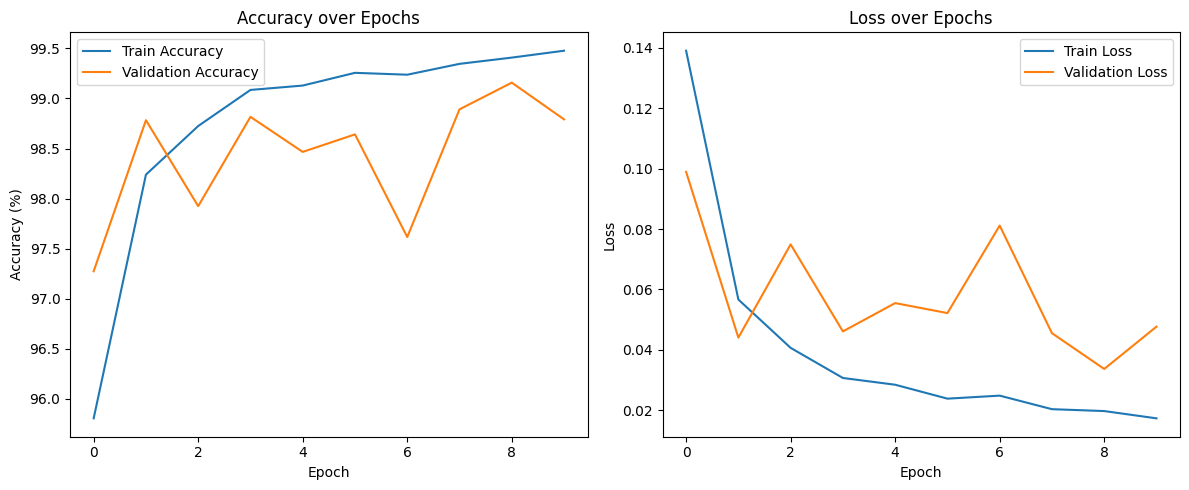

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using:", device)

num_epochs = 10
batch_size = 128
learning_rate = 0.001

# Dataset
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.QMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.QMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# ResNet18 Model
class ResNet18(nn.Module):
    def __init__(self):
        super(ResNet18, self).__init__()

        self.resnet = models.resnet18(weights=None)

        self.resnet.conv1 = nn.Conv2d(
            1, 64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        self.resnet.fc = nn.Linear(
            self.resnet.fc.in_features,
            10
        )

    def forward(self, x):
        return self.resnet(x)


# Hybrid Initialization
def custom_init(model):
    for module in model.modules():

        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(
                module.weight,
                mode='fan_out',
                nonlinearity='relu'
            )

        elif isinstance(module, nn.Linear):
            nn.init.orthogonal_(module.weight)

        if hasattr(module, 'bias') and module.bias is not None:
            nn.init.constant_(module.bias, 0)


model = ResNet18().to(device)
custom_init(model)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate
)

train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []


# Training
for epoch in range(num_epochs):

    model.train()

    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = 100 * correct / total

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)


    # Validation
    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100 * correct / total

    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )


# Test Accuracy
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total

print(f"\nFinal Test Accuracy: {test_acc:.2f}%")


# Graphs

plt.figure(figsize=(6,4))
plt.plot(train_loss_list)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(val_loss_list)
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_acc_list)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(val_acc_list)
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()